<a href="https://colab.research.google.com/github/alvarogmendez/magic_square_generator/blob/main/MagicSquareGenerator_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## References
[1] Tao Xie and Lishan Kang, "An evolutionary algorithm for magic squares," The 2003 Congress on Evolutionary Computation, 2003. CEC '03., Canberra, ACT, Australia, 2003, pp. 906-913 Vol.2, doi: 10.1109/CEC.2003.1299763.

[2] Cui, Xintian, Xiangqi Cheng, and Guoxuan Bu. "Research on Magic Square Construction Based on Genetic Algorithm." Academic Journal of Computing & Information Science 5.2 (2022): 77-80. Vol. 5, doi: 10.25236/AJCIS.2022.050212

# Magic Square Generator Notebook

### Author: Álvaro González Méndez

In this notebook, I will attempt to generate Magic Squares of order N using evolutionary algorithms. Initially, I will follow the design proposed in T. Xie and L. Kang's paper, "An Evolutionary Algorithm for Magic Squares" [1].

This project is part of an assignment for the *Busqueda Basada in Metaheuristicas* course.

## Setup

First, we will install and import the necessary dependencies for our experiments.

In [ ]:
!pip install numpy matplotlib tqdm
import numpy as np
import numpy.random as rnd
import copy
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

## Simple Evolutionary Algorithm

Now, I will follow T. Xie [1] paper and first I will implement an Evolutionary Algorithim based on **Evolution Estrategies** that will try to find a magic square of size NxN in one simple algorithm. According to the publication, this would be able to generate **High-Quality Magic Squares** but with a very high cost and with order under 10.

Lets create all the parameters wee need to use in our first experiments

In [ ]:
sqr_size = 3
s_deviaton = 3
p_mutation = 1
population = 10
global_delta = 10


### Individuals
An individual will be denoted *I*, It will consist of two difernt matrix, *M* containing the values of the Magic Square to be constructed, and *Δ* containing all the mutation variance values **σ**.
$${I = (M,Δ)}$$

In [ ]:
class individual:
  def __init__(self,size,starting_deviaton) -> None:
    self.size =size
    self.starting_deviaton = starting_deviaton
    ordered_numbers = np.arange(1, size**2+1)
    shuffled_numbers = np.random.permutation(ordered_numbers)
    self.M = shuffled_numbers.reshape((size,size))
    self.delta = np.full((size,size),starting_deviaton)
    self.c = (size*(size**2+1))/2
    self.max = size**2
    self.global_delta =0

    self.n_col = 0
    self.n_row = 0

    self.d1 = 1
    self.d2 = 1

A nice method to implement in order to experiment in a high level is a poblation initializer.

In [ ]:
def init_population(population,sqr_size,s_deviaton):
  individual_list = []
  for i in range(population):
    ind = individual(sqr_size,s_deviaton)
    individual_list.append(ind)
  return individual_list

Test if the class initializer works as intended

In [ ]:
individual_list= init_population(population,sqr_size,s_deviaton)
for I in individual_list:
  print(I.M)

[[8 2 4]
 [9 6 1]
 [3 7 5]]
[[4 9 8]
 [6 1 2]
 [3 5 7]]
[[6 4 9]
 [5 8 1]
 [3 7 2]]
[[7 2 6]
 [4 1 9]
 [8 5 3]]
[[9 1 7]
 [4 8 3]
 [2 5 6]]
[[6 5 9]
 [1 2 8]
 [3 7 4]]
[[3 5 2]
 [7 9 4]
 [6 8 1]]
[[3 9 2]
 [6 5 7]
 [1 8 4]]
[[9 7 1]
 [6 8 5]
 [2 4 3]]
[[3 8 2]
 [4 5 1]
 [6 9 7]]



### Fitness Function
Considering we are working only with Natural numbers and *c* is:
$${c = \frac{n(n²+1)}{2}}$$
And *a* is an element of the square which can be represented by a squared matrix *M* of size *n*:

$${M = \begin{bmatrix}
a_{11} & a_{12} & \dots & a_{1n} \\
a_{21} & a_{22} & \dots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{n1} & a_{n2} & \dots & a_{nn}
\end{bmatrix}}$$

To consider an square a  **High-Quality Magic Square** we must ensure that the following conditions are met.
$${\sum^n_{i=1}a_{ij}=c ,
\sum^n_{j=1}a_{ij}=c,
\sum^n_{i=1}a_{ii}=c,
\sum^n_{i=1}a_{i(n-i+1)}=c}$$
So we can define the next fitness function using this last restrictions:
$${f(M) = \sum^n_{i=1}\lvert c-\sum^n_{k=1}a_{ik}\rvert+
\sum^n_{j=1}\lvert c- \sum^n_{k=1}a_{kj}\rvert+
\lvert c-\sum^n_{i=1}a_{ii}\rvert+
\lvert c-\sum^n_{i=1}a_{i(n-i+1)}\rvert}$$


In [ ]:
# Fitness function
def fitness(individual):
  size = individual.size
  c = individual.c
  sum_rows = np.sum(individual.M,axis=1)
  sum_cols = np.sum(individual.M,axis=0)
  sum_diag = np.trace(individual.M)
  sum_antidiag = np.trace(np.fliplr(individual.M))
  fitness = int(np.sum(np.abs(c-sum_rows))+np.sum(np.abs(c-sum_cols))+np.abs(c-sum_diag)+np.abs(c-sum_antidiag))
  return fitness

Test fitness algorithm

In [ ]:
fitness_list = []
for individual in individual_list:
  fitness_list.append(fitness(individual))
print(fitness_list)

[18, 22, 22, 20, 16, 26, 30, 30, 33, 30]


The same way we did with the individual inizalizer, we will create a method that calculates the fitness of all individuals. Also, lets make this method to checks if there is a magic square in the population so it can be used as a our **stop condition**

In [ ]:
def population_fitness(individual_list):
  fitness_list = []
  for individual in individual_list:
    score = fitness(individual)
    if score == 0:
      return individual
    fitness_list.append(score)
  return fitness_list

### Selection Operator

We may use the **rulette method** or **stochastic universal sampling** for selecting the individuals that will be having offspring.

In this operator we must calculate the probability of each individual to get selected base on the evaluation of all the individuals and the fitness function. Following the method used by X. Cui et al. [2], we will use the next formula to calcullate each of:

$${p(I_n)= \frac{\frac{1}{f(M_n)}}{∑^n_{m=1}\frac{1}{f(M_m)}}}$$

Taking into account that if we get an *f = 0* we have found a magic square, the we should stop the execution of the algorithm and return this one

Once we have the all the probabilities *p* for each individual, we shall calculate the distance between selected individuals and a random starting point.

In [ ]:
def stochastic_universal_sampling(population, fitness_scores, n):
    selected_individuals = []
    # 1/fitness
    fitness_inv = 1 / np.array(fitness_scores)
    total_fitness = sum(fitness_inv)
    cumulative_probs = np.cumsum([f / total_fitness for f in fitness_inv])
    step_size = 1.0 / n
    start_pointer = np.random.uniform(0, step_size)
    pointers = [start_pointer + i * step_size for i in range(n)]
    individual_idx = 0

    for pointer in pointers:
        while cumulative_probs[individual_idx] < pointer:
            individual_idx += 1

        selected_individuals.append(population[individual_idx])

    return selected_individuals

Test universal stochastic sampling method (roulette)



In [ ]:
pool = stochastic_universal_sampling(individual_list, fitness_list, population)

for individual in pool:
  print(individual.M)

[[8 2 4]
 [9 6 1]
 [3 7 5]]
[[4 9 8]
 [6 1 2]
 [3 5 7]]
[[6 4 9]
 [5 8 1]
 [3 7 2]]
[[7 2 6]
 [4 1 9]
 [8 5 3]]
[[9 1 7]
 [4 8 3]
 [2 5 6]]
[[9 1 7]
 [4 8 3]
 [2 5 6]]
[[6 5 9]
 [1 2 8]
 [3 7 4]]
[[3 9 2]
 [6 5 7]
 [1 8 4]]
[[9 7 1]
 [6 8 5]
 [2 4 3]]
[[3 8 2]
 [4 5 1]
 [6 9 7]]


### Mutation Operator

As we are using an Evoluitonary Estrategy, we do not have a crossover operator, so the only way we can explore/explote new solutions in our space is by mutation. This leads to kind of a random search.

We will call *I'* to the offspring of *I* we will also have *M'* and *Δ'* :

$${I=(M,Δ)→I'=(M',Δ')}$$

Both *M'* and *Δ'* will have the updated values of each value *a* and its correspondig mutation variance. In each generation some individuals will randomly be selected to mutate based on `p_mutation` which is the probability to be selected to enter the mutation operator.

Once an Individual is selected to mutate, randomply the algorithm will select a value a and will change the offspring's value based on the following calculation:

$${a'_{ij} = a_{ij}+rand(-σ_{ij},σ_{ij})}$$

Being *rand(a,b)* a funtion that calculates a natural number between *a* and *b*. Also we have to take care about generating numbers out of range, so if any number is bellow 1, we shound use:

$${a'_{ij} = rand(1,n)}$$

In the same way, if we reach a value above n^2 we must:

$${a'_{ij} = n^2 - rand(0,n)}$$

Next we will have to search the new generated value and sustitude its value with *a*'s original value so we can still have all diferent numbers.

Finally, we will have to udate the values of our *σ*, the way of doing this is by:

$${σ'_{ij} = σ_{ij} + rand(-1,1)}$$
$${σ'_{ij} < 1 → σ'_{ij}=1}$$



In [ ]:
def mutation(individual_list,probability):
  for individual in individual_list:
    if np.random.random() < probability:
      i = np.random.randint(0,individual.size)
      j = np.random.randint(0,individual.size)
      old_value = individual.M[i,j]
      new_value = old_value
      while new_value == old_value:
        new_value = old_value + np.random.randint(-individual.delta[i,j],individual.delta[i,j])
        if new_value < 1:
          new_value = np.random.randint(1,individual.size)
        elif new_value > individual.max:
          new_value = individual.max - np.random.randint(0,individual.size)
      k,l = np.where(individual.M == new_value)
      individual.M[i,j] = new_value
      individual.M[k,l] = old_value
      vary = np.random.randint(-1,2)
      new_delta = individual.delta[i,j] + vary
      if new_delta < 1:
        new_delta = 1
      individual.delta[i,j] = new_delta


Testing our mutation algorithm

In [ ]:
p_mutation = 1 # Forcing to mutate every cicle (just for testing)
print("Before mutation")
for I in individual_list:
  print(I.M)
mutation(individual_list,p_mutation)
print("After mutation")
for I in individual_list:
  print(I.M)
  print("delta")
  print(I.delta)

Before mutation
[[8 2 4]
 [9 6 1]
 [3 7 5]]
[[4 9 8]
 [6 1 2]
 [3 5 7]]
[[6 4 9]
 [5 8 1]
 [3 7 2]]
[[7 2 6]
 [4 1 9]
 [8 5 3]]
[[9 1 7]
 [4 8 3]
 [2 5 6]]
[[6 5 9]
 [1 2 8]
 [3 7 4]]
[[3 5 2]
 [7 9 4]
 [6 8 1]]
[[3 9 2]
 [6 5 7]
 [1 8 4]]
[[9 7 1]
 [6 8 5]
 [2 4 3]]
[[3 8 2]
 [4 5 1]
 [6 9 7]]
After mutation
[[8 2 6]
 [9 4 1]
 [3 7 5]]
delta
[[3 3 3]
 [3 4 3]
 [3 3 3]]
[[4 9 8]
 [6 2 1]
 [3 5 7]]
delta
[[3 3 3]
 [3 2 3]
 [3 3 3]]
[[6 4 9]
 [8 5 1]
 [3 7 2]]
delta
[[3 3 3]
 [3 4 3]
 [3 3 3]]
[[7 2 6]
 [5 1 9]
 [8 4 3]]
delta
[[3 3 3]
 [4 3 3]
 [3 3 3]]
[[6 1 7]
 [4 8 3]
 [2 5 9]]
delta
[[3 3 3]
 [3 3 3]
 [3 3 3]]
[[6 5 9]
 [2 1 8]
 [3 7 4]]
delta
[[3 3 3]
 [4 3 3]
 [3 3 3]]
[[3 4 2]
 [7 9 5]
 [6 8 1]]
delta
[[3 3 3]
 [3 3 4]
 [3 3 3]]
[[3 9 4]
 [6 5 7]
 [1 8 2]]
delta
[[3 3 3]
 [3 3 3]
 [3 3 2]]
[[6 7 1]
 [9 8 5]
 [2 4 3]]
delta
[[2 3 3]
 [3 3 3]
 [3 3 3]]
[[3 8 4]
 [2 5 1]
 [6 9 7]]
delta
[[3 3 4]
 [3 3 3]
 [3 3 3]]


## Test and Conclusions of the Simple Evolutionary Algorithm

Now, we have every operator implemented, we can try to solve small **High-Quality Magic Squares**.

In [ ]:
# Modify our hyperparameters
sqr_size = 3
s_deviaton = 3
population = 1000
p_mutation = 1
max_iterations = 1000
total_min = 10000000

individuals = init_population(population,sqr_size,s_deviaton)
min_fitnes_list = []

for i in tqdm(range(max_iterations),desc="Generation"):
  individuals_score = population_fitness(individuals)
  if type(individuals_score) == individual:
    print("Magic Square Found")
    print(individuals_score.M)
    break

  min = np.min(individuals_score)
  min_fitnes_list.append(min)
  if min < total_min:
    total_min = min
    pointer = individuals_score.index(min)
    print(f"Iteracion: {i} Min fitness: {min}")
    print(individuals[pointer].M)

  selected_individuals = stochastic_universal_sampling(individuals,individuals_score,population)
  mutation(selected_individuals,p_mutation)
  individuals = selected_individuals

plt.plot(min_fitnes_list)
plt.title("Min Fitness evolution")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.show()

TypeError: 'individual' object is not callable

Observing the algorithm behavior we can asume the next things:

*   If we increase the probability of a mutation to happen, the averge and minimun values of the fitness for each epoch behavior is more erratic and we will search in our solution space randomly, so we must choose a small mutation probability.
*   At this moment it has an extreme cost to generate low order high-quality magic squares.
*   Our individuals' fitness indicates that we are searching almost in a random way, so we are far away from the objective.

After a coulple of experiments, we can asume this algorithm can generate magic squares, but at a extreme cost and only in squares of low order (3 and 4)In T. Xie's paper the author says:

> A simple evolutionary algorithm hardly succeeds in
constructing magic squares of orders more than 10, and
the evolving efficiency and the success rate are also
extremely low. [1]

We must search for another method tha can generate bigger squares. The way of doing this will be on separating the problem in multiple steps that are simplier.



## Improved Evolutionary Algorithm

Both papers T. Xie [1] and X. Cui [2] propose a two step algorithm that first find a **Inferior Magic Square**(only the sum of each colum and each row is the same) using a very similar algorithm to the one already implemented in this file which alters the fitness function, and later using another Genetic Algorithm it make permutation to transform the output of the first part into an **High-Quality Magic Square**.

In order to make this algorithm to work we will add two parameters to each individual `n_cols` and `n_rows` this two indicates the number of columns and rows respectively that do not satisfy the magic sum. this change has already been added in the first implementation, but not the method to update these values. Here we can see a preliminar implementation of it and test:

In [ ]:
def update_ns_pre(individual):
    col_sums = np.sum(individual.M,axis=0) - individual.c
    row_sums = np.sum(individual.M,axis=1) - individual.c
    individual.n_col = np.count_nonzero(col_sums)
    individual.n_row = np.count_nonzero(row_sums)

In [ ]:
v =1
update_ns_pre(individual_list[1])
print(individual_list[v].M)
print(f"n_row: {individual_list[v].n_row}")
print(f"n_col: {individual_list[v].n_col}")

[[4 9 8]
 [6 2 1]
 [3 5 7]]
n_row: 2
n_col: 3


### First Evolution Fitness Function

In this stem we basically take the model implemented previously and change the fitness funtion in order to only satisfy the first two conditions of the magic squares, making our constrains be:

$${\sum^n_{i=1}a_{ij}=c ,
\sum^n_{j=1}a_{ij}=c}$$

Making a fitness funciton based on these two rules:

$${f.o. = \sum^n_{i=1}\lvert c-\sum^n_{k=1}a_{ik}\rvert+
\sum^n_{j=1}\lvert c- \sum^n_{k=1}a_{kj}\rvert}$$

In [ ]:
# Fitness function
def first_fitness(individual):
  size = individual.size
  c = individual.c
  sum_rows = np.sum(individual.M,axis=1)
  sum_cols = np.sum(individual.M,axis=0)
  fitness = int(np.sum(np.abs(c-sum_rows))+np.sum(np.abs(c-sum_cols)))
  return fitness

The same way we did with the first aproach of the project, we will create a method that calculates the fitness of all individuals. Also, lets make this method to checks if there is a magic square in the population so it can be used as the **stop condition** of the first step.

In [ ]:
def first_population_fitness(individual_list):
  fitness_list = []
  for individual in individual_list:
    score = first_fitness(individual)
    if score == 0:
      return individual
    fitness_list.append(score)
  return fitness_list

### First Evolution Mutation Operator
As the seletion operator still the same, I will not implement it again. But the mutation operator is subject to change.

Looking at our old mutation operator we observe that most of the time the operator choose to change numbers that are in a correct position, so we need to make our operator to mutate over the numbers that do not satisfy our objective. We can clasify our values contained in *M* as three diferent types:


*   **Type 1** → Elements that do not satisfy both condition
*   **Type 2** → Elements that do not satisfy any condition
*   **Type 3** → Elements that satisfy both conditions

The mathematical way of representing this types as sets S numbers is:

$${S_1 =\left\{a_{ij}:\sum^n_{k=1}a_{ik}\neq c, \sum^n_{k=1}a_{kj}\neq c, 1 \leq i,j\leq n\right\} }$$

$${S_2 = \left\{ a_{i*}: \sum^n_{k=1}a_{ik}\neq c,1 \leq i\leq n\right\} \cup \left\{ a_{*j}: \sum^n_{k=1}a_{kj}\neq c,1 \leq j\leq n\right\}}$$

$${S_3 = \left\{ a_{i*}: \sum^n_{k=1}a_{ik}= c,1 \leq i\leq n\right\} \cap \left\{ a_{*j}: \sum^n_{k=1}a_{kj}= c,1 \leq j\leq n\right\}}$$

Istead of creating a method that creates the first two set by giving an individual, we will update the `ns_update_pre` mehtod and create `ns_update`, that apart from updating `n_rows` and `n_cols` also returns *S1* and *S2* lists

In [ ]:
def ns_update(individual):
  col_sums = np.sum(individual.M,axis=0) - individual.c
  row_sums = np.sum(individual.M,axis=1) - individual.c
  individual.n_col = np.count_nonzero(col_sums)
  individual.n_row = np.count_nonzero(row_sums)
  S1 = set()
  S2 = set()
  col_list = []
  row_list = []
  for it in range(individual.size):
    if col_sums[it] != 0:
      S2.update(individual.M[:,it])
      col_list.append(it)
    if row_sums[it] != 0:
      S2.update(individual.M[it])
      row_list.append(it)
  for j in col_list:
    for i in row_list:
      S1.add(individual.M[i,j])
  return S1,S2

In [ ]:
v = 2
print(individual_list[v].M)

bS1, bS2 = ns_update(individual_list[v])
print(bS1)
print(bS2)

[[6 4 9]
 [8 5 1]
 [3 7 2]]
{np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}
{np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}


Depending on the sets *S1* and *S2* the individual can perfon 3 diferent permutations as our mutation operator, each permutation with a diferent probability based on `n_rows` and `n_cols`.

#### First Permutation
The algorithm chooses a random number in the *S1* set and mutates the same way we did in the single mutation operator. If the value given by the mutation is contained in *S2* the algorithm swaps them, if not, the mutated value will be replaced by the nearest element in *S2*. The probability of this permutation to happend is:

$${p_{m} = \frac{1}{n_{row}n_{col}}}$$


#### Second Permutation
The procedure in the second permutation is the same as the first but instead of choosing our value to mutate from *S1* we take it from *S2* and the same way, swaping it with the nearest of the mutated from *S3*. The probability of this permutation to happend is per row:

$${p_{m} = \frac{1}{nn_{col}} + \frac{1}{nn_{row}}}$$

#### Third Permutation
Quite similar to the last two, but this time we choose a number from *S2* mutate it, then swap it with the number obtained no mater if it is not contained in *S1* or *S2*. The probability of this permutation to happend the same as the second permutation:

$${p_{m} = \frac{1}{nn_{col}} + \frac{1}{nn_{row}}}$$

#### Updating σ Values

As we did in the Simple Evolutionary Algorithm we must change the values of our diferent σ but altering this last behaivour. In all three permutations we will update them the same way. Also we will be adding as a parameter global deviation σₜ.

$${σ'_{ij} = σ_{ij} + rand(-1,1)}$$
$${σ'_{ij} < 1 → σ'_{ij}=rand(1,σ_t)}$$
$${σ'_{ij} > σ_t → σ'_{ij}=rand(1,σ_t)}$$

And later we must calculate our global deviation σₜ:

$${σ_t = \frac{1}{n_{col}+n_{row}}\left(\sum^n_{i=1}\lvert c-\sum^n_{k=1}a_{ik}\rvert+
\sum^n_{j=1}\lvert c- \sum^n_{k=1}a_{kj}\rvert\right)}$$

So, with all needed explained, we must implement:

In [ ]:
def find_nearest(elem_set, searched, old):
    nearest = None
    least_diff = int(100000000)
    for elem in elem_set:
        diff = abs(elem - searched)
        #if diff < least_diff :
        if diff < least_diff and elem != old:
            least_diff = diff
            nearest = elem
    return least_diff

In [ ]:
def update_global_delta(individual):
  c = individual.c
  sum_rows = np.sum(individual.M,axis=1)
  sum_cols = np.sum(individual.M,axis=0)
  new_global_delta = np.ceil(np.sum(np.abs(c-sum_rows))+np.sum(np.abs(c-sum_cols))/(individual.n_col+individual.n_row))
  #print(new_global_delta)
  #if new_global_delta == 0: return 1
  return new_global_delta


In [ ]:
def first_mutation(individual_list,probability):
  for individual in individual_list:
    if np.random.random() < probability:
      S1,S2 = ns_update(individual)
      permutations = [1,2]
      p1= 0
      p2= 0
      if individual.n_row != 0 or individual.n_col != 0:
        if individual.n_row == 0:
          p2 = 1/(individual.n_col*individual.size)
        elif individual.n_col == 0:
          p2 = 1/(individual.n_row*individual.size)
        else:
          p1 = 1/(individual.n_col*individual.n_row)
          p2 = 1/(individual.n_col*individual.size) +1/(individual.n_row*individual.size)
          permutations.append(0)
        permutation = np.random.choice(permutations)
        if permutation == 0:
          mut_set = list(S1)
          out_set = list(S2)
          p = p1
        elif permutation == 1:
          mut_set = list(S2)
          out_set = list(S2)
          p = p2
        else:
          mut_set = list(S2)
          out_set = list(range(1,individual.max+1))
          p = p2
        for elem in mut_set:
          if np.random.random() < p:
            i,j = np.where(individual.M == elem)
            old_value = individual.M[i,j]
            new_value = old_value
            new_value = old_value + np.random.randint(-individual.delta[i,j],individual.delta[i,j])
            if new_value < 1:
              new_value = np.random.randint(1,individual.size)
            elif new_value > individual.max:
              new_value = individual.max - np.random.randint(0,individual.size)

            if new_value not in out_set:
              new_value = find_nearest(out_set,new_value,old_value)
            k,l = np.where(individual.M == new_value)
            individual.M[i,j] = new_value
            individual.M[k,l] = old_value
            vary = np.random.randint(-1,2)
            new_delta = individual.delta[i,j] + vary
            global_delta = int(update_global_delta(individual))
            if new_delta < 1 or new_delta > global_delta :
              if global_delta < 2:
                new_delta = 1
              else:
                new_delta = np.random.randint(1,global_delta)
            individual.delta[i,j] = new_delta
            # global_delta = 100


### Selection Operator

We will use a selector that gets only the best n solution's eliminating the stochastic method by this deterministic.

In [ ]:
def get_best(population, fitness_scores, n):
    pairs = list(zip(fitness_scores, population))
    ordered_pairs = sorted(pairs, key=lambda pairs: pairs[0])
    best_pairs = ordered_pairs[:n]
    best_fitness, selected_individuals = zip(*best_pairs)
    return selected_individuals

Once this first part is tested we must implement the second one, but we can observe that the cost is quite big compared to T. Xie et al. paper[1]. Diggin up in their implementation, they allso add a method that do some extra permutations when the solution converges. They call this mechanism 'Local Rectification'
### Local Rectification of Rows and Columns
As it is said in the paper mentioned [1]:



> At the late stage of an evolutionary algorithm, evolution usually stagnates or periodically oscillates. If the heuristics of magic square can be used to locally rectify the intermediate configuration in the late stages of both the two phases, the locally searching efficiency can be greatly improved.

>By a process of analyzing all rows and columns, a local
rectification is made if two rows or columns can meet the
magic sum when more than one pair of numbers is
interchanged.

So lets make this change in our algorithm.

The first type of local rectification over columns and rows is **swapping one pair of values** that are in the same column/row that are the values needed in the other column/row:

Being *k* and *l* two rows and *s* a column that contains two numbers that can be swapped.

$${\sum^n_{i=1}a_{ki}-c =c-\sum^n_{j=1}a_{lj} = a_{ks}-a_{ls}}$$

Happens the same with *k* and *l* as columns and *s* as a row.

$${\sum^n_{i=1}a_{ik}-c =c-\sum^n_{j=1}a_{jl} = a_{sk}-a_{sl}}$$

Furthermore, we can make another type of swap for our rows and columns, these can **swap two pair of values**.

The same way, this two pairs must be in the rows *k* and *l* and will correspond to the columns *s* and *t*.

$${\sum^n_{i=1}a_{ki}-c =c-\sum^n_{j=1}a_{lj} = a_{ks}+a_{kt}-a_{ls}-a_{lt}}$$

And with the cols *k* and *l* with columns *s* and *t*.

$${\sum^n_{i=1}a_{ik}-c =c-\sum^n_{j=1}a_{jl} = a_{sk}+a_{tk}-a_{sl}-a_{tl}}$$

In [ ]:
def local_rectification(individual):
    M = individual.M
    n = individual.size
    c = individual.c
    filas_con_error_indices = [i for i in range(n) if sum(M[i]) != c]

    for i in range(len(filas_con_error_indices)):
        for j in range(i + 1, len(filas_con_error_indices)):
            k = filas_con_error_indices[i]
            l = filas_con_error_indices[j]

            error_k = sum(M[k]) - c
            error_l = sum(M[l]) - c

            if error_k == -error_l:
                found_one_pair = False
                for s in range(n):
                    num_ks = M[k][s]
                    num_ls = M[l][s]
                    if (num_ks - num_ls) == error_k:
                        M[k][s], M[l][s] = M[l][s], M[k][s]
                        found_one_pair = True
                        break

                if found_one_pair:
                    continue

                found_two_pairs = False
                for s in range(n):
                    for t in range(s + 1, n):
                        num_ks = M[k][s]
                        num_ls = M[l][s]
                        num_kt = M[k][t]
                        num_lt = M[l][t]

                        if (num_ks + num_kt) - (num_ls + num_lt) == error_k:
                            M[k][s], M[l][s] = M[l][s], M[k][s]
                            M[k][t], M[l][t] = M[l][t], M[k][t]
                            found_two_pairs = True
                            break
                    if found_two_pairs:
                        break

Now we need to find a way to make this new fixed permutation to happend on our execution flow. T. Xie [1] specifies that this permutation start happening when the fitnes is **under 50 times the size of the square** so adding to the algothim this condition we can try:

In [ ]:
# Modify our hyperparameters
SEED = 5

np.random.seed(SEED)

sqr_size = 9
s_deviaton = sqr_size**2
population = 1
offspring_num = sqr_size * 1
din_offspring_limit = sqr_size / 2
p_mutation = 1
max_iterations = 100000
total_min = 10000000

individuals = init_population(population,sqr_size,s_deviaton)
min_fitnes_list = []

pbar = tqdm(range(max_iterations),desc="Generation")
try:
    for i in pbar:
      individuals_score = first_population_fitness(individuals)
      # print(individuals_score)
      if type(individuals_score) == individual:
        print("Magic Square Found")
        print(individuals_score.M)
        break

      individual_fitness = individuals_score[0]
      min_fitnes_list.append(individual_fitness)
      if individual_fitness < total_min:
        total_min = individual_fitness
        pointer = individuals_score.index(individual_fitness)
        pbar.set_postfix(min_epoch=i,min_fitness=individual_fitness)

      selected_individuals = get_best(individuals,individuals_score,population)
      if individual_fitness < 50 * sqr_size:
        for elem in selected_individuals:
          local_rectification(elem)
      individuals = []
      offspring = []

      for elem in selected_individuals:
        for i in range(offspring_num):
          offspring.append(copy.deepcopy(elem))

      first_mutation(offspring,p_mutation)
      # print(f"min: {min}")
      if individual_fitness < 50 * sqr_size and individual_fitness > sqr_size:
        #individuals.extend(selected_individuals)
        individuals.extend(offspring)

        # print("< 50 x n")
        # print(f"Ind: {individuals}")
        # print(f"Off: {offspring}")
      else:
        # print("> 50 x n")
        individuals = offspring
finally:
    plt.plot(min_fitnes_list)
    plt.title("Min Fitness evolution")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.show()


Yet on the point we are right now, we can obtain **Low-Quality Magic Squares** under order of **30** almost all the times we execute the code. As I do not want to keep improving we can move to the second part of the algorithm.

### Second Evolution
Now we need to add our last two restirctions to the magic squares in order to find a **High-Quality** or **Full Magic Square**

$${\sum^n_{i=1}a_{ii}=c,
\sum^n_{i=1}a_{i(n-i+1)}=c}$$

In this part we will not use any random number mutation because this can lead to break the previous non **High-Quality Magic Squares** which are the base of the final ones.


### Second Evolution Fitness Function
As said before we must declare a new fitness funtion for the diagonals, this is:

$${f(M)= \lvert c-\sum^n_{i=1}a_{ii}\rvert+
\lvert c- \sum^n_{k=i}a_{i,(n-i+1)}\rvert}$$

Also we need to add to our individual implementation `d1` and `d2` which determines if the squares diagonals sum up to *c* in the way:

$${\sum^n_{i=1}a_{ii}=c → d_1 = 0, \sum^n_{i=1}a_{ii}\neq c → d_1 = 1}$$

$${\sum^n_{i=1}a_{i(n-i+1)}=c → d_2 = 0, \sum^n_{i=1}a_{i(n-i+1)}\neq c → d_2 = 1}$$


And implement it:

In [ ]:
def second_fitness(individual):
  size = individual.size
  c = individual.c
  sum_diag = np.trace(individual.M)
  sum_antidiag = np.trace(np.fliplr(individual.M))
  fitness = int(np.abs(c-sum_diag)+np.abs(c-sum_antidiag))
  if sum_diag == 0: individual.d1 = 1
  else: individual.d1 = 0
  if sum_antidiag == 0: individual.d2 = 1
  else: individual.d2 = 0
  return fitness

Also a method to evaluates all the individuals respect to the new fitnes function:

In [ ]:
def second_population_fitness(individual_list):
  fitness_list = []
  for individual in individual_list:
    score = second_fitness(individual)
    if score == 0:
      return individual
    fitness_list.append(score)
  return fitness_list

### Second Evolution Mutation Operator
This operator is simplier than the first mutation operator, as we want to keep the sum values for our rows and columns, we will search the diagonals by permuting rows and columns so each elemnt will stay in the same row/column even if we move it.

As told, we have two new permutations that will make the mutation operator work.
* Row Permutation → As it is named, this method will permutate two rows of the individual's matrix *M*.
* Column Permutation → Basically it is the same as the row permutation but with columns.

Our operator will randomly choose two rows/columns and swap them in the individual's genoma (matrix).

This operator will be used while:

$${n_{col} + n_{row} = 0,\space d_1 + d_2 \geq 1}$$

In [ ]:
def second_mutation(individual_list):
  for individual in individual_list:
    M = individual.M
    axis = np.random.randint(0, 2)
    if axis == 0:
        idx1, idx2 = np.random.choice(individual.size, size=2, replace=False)
        M[[idx1, idx2], :] = M[[idx2, idx1], :]
    else:
        idx1, idx2 = np.random.choice(individual.size, size=2, replace=False)
        M[:, [idx1, idx2]] = M[:, [idx2, idx1]]

### Local Rectification of Diagonals
Also it is posible to implement local rectification for our diagonals as we did for the columns and rows. We have the next 5 rectifications:

#### 1. Row Swap to Correct Diagonals
Row $i$ is swapped with row $j$ if the resulting change in both diagonals exactly matches the error they need to correct.
$$(a_{ii}+a_{jj})-(a_{ij}+a_{ji}) = \sum_{k=1}^{n}a_{kk}-c \quad \text{and}$$
$$(a_{i,n-i+1}+a_{j,n-j+1})-(a_{i,n-j+1}+a_{j,n-i+1}) = \sum_{k=1}^{n}a_{n-k+1,k}-c$$

#### 2. Column Swap to Correct Diagonals
Similarly, column $i$ is swapped with column $j$ if the following conditions for both diagonals are met.
$$(a_{ii}+a_{jj})-(a_{ij}+a_{ji}) = \sum_{k=1}^{n}a_{kk}-c \quad \text{and}$$
$$(a_{n-i+1,i}+a_{n-j+1,j})-(a_{n-j+1,i}+a_{n-i+1,j}) = \sum_{k=1}^{n}a_{n-k+1,k}-c$$

#### 3. Symmetrical Row Swap
Row $i$ is swapped with its symmetrical row $(n-i+1)$ if the change in the main diagonal equals its error, and this error is opposite to that of the inverse diagonal.
$$(a_{ii}+a_{n-i+1,n-i+1})-(a_{i,n-i+1}+a_{n-i+1,i}) = \sum_{k=1}^{n}a_{kk}-c = c-\sum_{k=1}^{n}a_{n-k+1,k}$$

#### 4. 4-Point Swap (Main Diagonal)
A localized swap of four numbers is performed to correct the main diagonal if the following equality is met.
$$(a_{ii}+a_{jj})-(a_{ij}+a_{ji}) = \sum_{k=1}^{n}a_{kk}-c$$

#### 5. 4-Point Swap (Inverse Diagonal)
Analogously, another four-number swap is performed to correct the inverse diagonal if this condition is met.
$$(a_{i,n-i+1}+a_{n-j+1,j})-(a_{ij}+a_{n-j+1,n-i+1}) = \sum_{k=1}^{n}a_{n-k+1,k}-c$$

Implementing them as:


In [ ]:
def _calculate_diagonal_errors(ind):
    sum_main_diag = np.trace(ind.M)
    sum_anti_diag = np.trace(np.fliplr(ind.M))
    error_main = ind.c - sum_main_diag
    error_anti = ind.c - sum_anti_diag
    return int(error_main), int(error_anti)

def local_rectification_diagonals(ind):
    error_main, error_anti = _calculate_diagonal_errors(ind)
    if error_main == 0 and error_anti == 0:
        return False

    if _rectify_by_row_swap(ind, error_main, error_anti):
        return True

    if _rectify_by_col_swap(ind, error_main, error_anti):
        return True

    if _rectify_by_symmetrical_row_swap(ind, error_main, error_anti):
        return True

    return False

def _rectify_by_row_swap(ind, error_main, error_anti):
    for i in range(ind.size):
        for j in range(i + 1, ind.size):
            change_main = (ind.M[i, j] + ind.M[j, i]) - (ind.M[i, i] + ind.M[j, j])
            change_anti = (ind.M[i, ind.size - 1 - j] + ind.M[j, ind.size - 1 - i]) - (ind.M[i, ind.size - 1 - i] + ind.M[j, ind.size - 1 - j])
            if change_main == error_main and change_anti == error_anti:
                ind.M[[i, j]] = ind.M[[j, i]]
                return True
    return False

def _rectify_by_col_swap(ind, error_main, error_anti):
    for i in range(ind.size):
        for j in range(i + 1, ind.size):
            change_main = (ind.M[j, i] + ind.M[i, j]) - (ind.M[i, i] + ind.M[j, j])
            change_anti = (ind.M[ind.size - 1 - i, j] + ind.M[ind.size - 1 - j, i]) - (ind.M[ind.size - 1 - i, i] + ind.M[ind.size - 1 - j, j])
            if change_main == error_main and change_anti == error_anti:
                ind.M[:, [i, j]] = ind.M[:, [j, i]]
                return True
    return False

def _rectify_by_symmetrical_row_swap(ind, error_main, error_anti):
    for i in range(ind.size // 2):
        j = ind.size - 1 - i
        change_main = (ind.M[i, j] + ind.M[j, i]) - (ind.M[i, i] + ind.M[j, j])
        if change_main == error_main and error_main == -error_anti:
            ind.M[[i, j]] = ind.M[[j, i]]
            return True
    return False

Generation:   0%|          | 0/100000 [00:00<?, ?it/s]

No Quality Magic Square Found on Epoch 1973
[[71 18 12 33 63 79  8 41 44]
 [74 16 13 19 47 37 65 76 22]
 [30 56 55 69 24 68 42  2 23]
 [ 5 62 81 61 67 35 51  4  3]
 [31 66 64 40 52 17 36 38 25]
 [ 9 46 34 50 57 21 53 60 39]
 [73 32 72  7 10 15 29 54 77]
 [ 1 45 27 20 43 49 26 80 78]
 [75 28 11 70  6 48 59 14 58]]
Magic Square Found on Epoch 5292
[[ 4 35 62 67  5  3 61 81 51]
 [41 79 18 63 71 44 33 12  8]
 [14 48 28  6 75 58 70 11 59]
 [76 37 16 47 74 22 19 13 65]
 [ 2 68 56 24 30 23 69 55 42]
 [80 49 45 43  1 78 20 27 26]
 [38 17 66 52 31 25 40 64 36]
 [60 21 46 57  9 39 50 34 53]
 [54 15 32 10 73 77  7 72 29]]


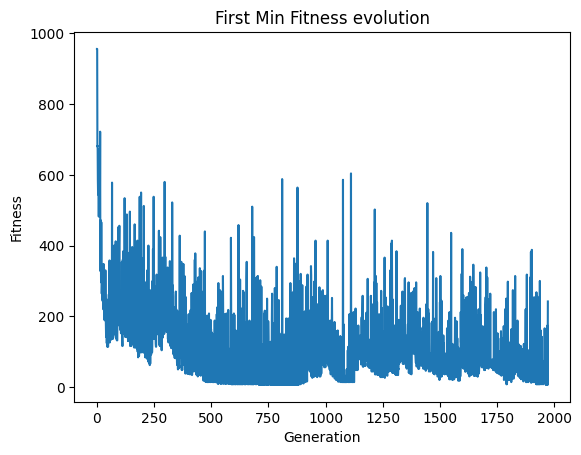

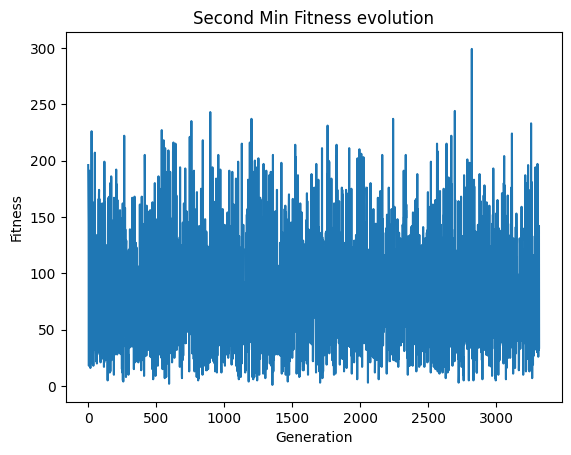

In [ ]:
SEED = 9213244

np.random.seed(SEED)

sqr_size = 9
s_deviaton = sqr_size**2
population = 1
offspring_num = sqr_size * 1
din_offspring_limit = sqr_size / 2
p_mutation = 1
max_iterations = 100000
first_min = 10000000
second_min = 10000000
phase_flag = False # If phase_flag == True we are on second phase

individuals = init_population(population,sqr_size,s_deviaton)
min_fitness_list_first = []
fitness_list_first = []
min_fitness_list_second = []
fitness_list_second = []

pbar = tqdm(range(max_iterations),desc="Generation")
try:
  for i in pbar:
    if not phase_flag:
      individuals_score = first_population_fitness(individuals)
      if type(individuals_score) == individual:
        print(f"No Quality Magic Square Found on Epoch {i}")
        print(individuals_score.M)
        phase_flag = True
        continue

      individual_fitness = individuals_score[0]
      fitness_list_first.append(individual_fitness)
      min_fitness_list_first.append(first_min)
      if individual_fitness < first_min:
        first_min = individual_fitness
        pointer = individuals_score.index(individual_fitness)
        pbar.set_postfix(min_epoch1=i,min_fitness1=individual_fitness)

      selected_individuals = get_best(individuals,individuals_score,population)
      if individual_fitness < 50 * sqr_size:
        for elem in selected_individuals:
          local_rectification(elem)
      individuals = []
      offspring = []

      for elem in selected_individuals:
        for i in range(offspring_num):
          offspring.append(copy.deepcopy(elem))

      first_mutation(offspring,p_mutation)
      if individual_fitness < 50 * sqr_size and individual_fitness > sqr_size:
        #individuals.extend(selected_individuals)
        individuals.extend(offspring)
      else:
        individuals = offspring
    else:
      individuals_score = second_population_fitness(individuals)
      if type(individuals_score) == individual:
        print(f"Magic Square Found on Epoch {i}")
        print(individuals_score.M)
        break

      individual_fitness = individuals_score[0]
      min_fitness_list_second.append(second_min)
      fitness_list_second.append(individual_fitness)
      if individual_fitness < second_min:
        second_min = individual_fitness
        pointer = individuals_score.index(individual_fitness)
        pbar.set_postfix(min_epoch2=i,min_fitness2=individual_fitness)

      selected_individuals = get_best(individuals,individuals_score,population)
      if individual_fitness < 10:#* sqr_size:
        for elem in selected_individuals:
          local_rectification_diagonals(elem)
      individuals = []
      offspring = []

      for elem in selected_individuals:
        for i in range(offspring_num):
          offspring.append(copy.deepcopy(elem))

      second_mutation(offspring)
      if individual_fitness < 50 * sqr_size and individual_fitness > sqr_size:
        #individuals.extend(selected_individuals)
        individuals.extend(offspring)
      else:
        individuals = offspring
finally:
    plt.plot(fitness_list_first)
    plt.title("First Min Fitness evolution")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.show()
    plt.plot(fitness_list_second)
    plt.title("Second Min Fitness evolution")
    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.show()

Now we can finally put all together on a `.py` file and say we are done with it.

## Conclusions
Following the recipe written in 2003 of T. Xie [1] we did not get results as good as the author but, indeed, we ended up with a more than suficient implementation of a Magic Square Generator.

We tried to generate squares of order 30 succesfully under 20 minutes which might look very time wasting, but comparing to a brute force seach it is infinitly more efficient. There is a total of 900! posible combinations of squares of this size.

$${900! ≈ 1.45×10^{2274}}$$

To put this number into perspective, let us make an exceedingly optimistic assumption about computational speed. Let us asume a hypothetical supercomputer capable of evaluating one Spanish Billion (U.S. trillion) combinations per second. The total time required in years would be calculated using the following operation:

$$ \text{Time (years)} = \frac{1.45 \times 10^{2274} \text{ combinations}}{10^{12} \text{ combinations/sec} \times 31,536,000 \text{ sec/year}} \approx 4.6 \times 10^{2254} \text{ years} $$

For context, the estimated age of the universe is approximately 13800 million years.

$$ \text{Age of Universe (years)} = 1.38 \times 10^{10} $$

Therefore, the time necessary to find a 30x30 magic square by brute force is orders of magnitude greater than the age of the universe, rendering such an approach computationally infeasible.

However in the paper the author mentions he es able to create squares of orther 100. No doubting in their research, the important points that I coud have done better and could be object to improve are:

* Make an implementation in a not interpretated lenguage such as C or Java instead of Python.

* Search for errors in my implementation.

* Optimize the code for more efficent computing.

* Use of concurrent methods.

* Use of prepaired libraries such as *DEAP*, *PyGAD*, and *EvoPy*.

* Even further than comparing to T. Xie et al, search of a diferent metaheuristic that can solve the problem more efficiently.
